Dataset Overview
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape: (768, 9)

Dataset Summary Stats:
                          count        mean         std     min       25%  \
Pregnancies               768.0    3.845052    3.369578   0.000   1.00000   
Glucose                   768.0  120.894531   31.972618   0.000  99.00000   
BloodP

/tmp/ipykernel_618/2669745213.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


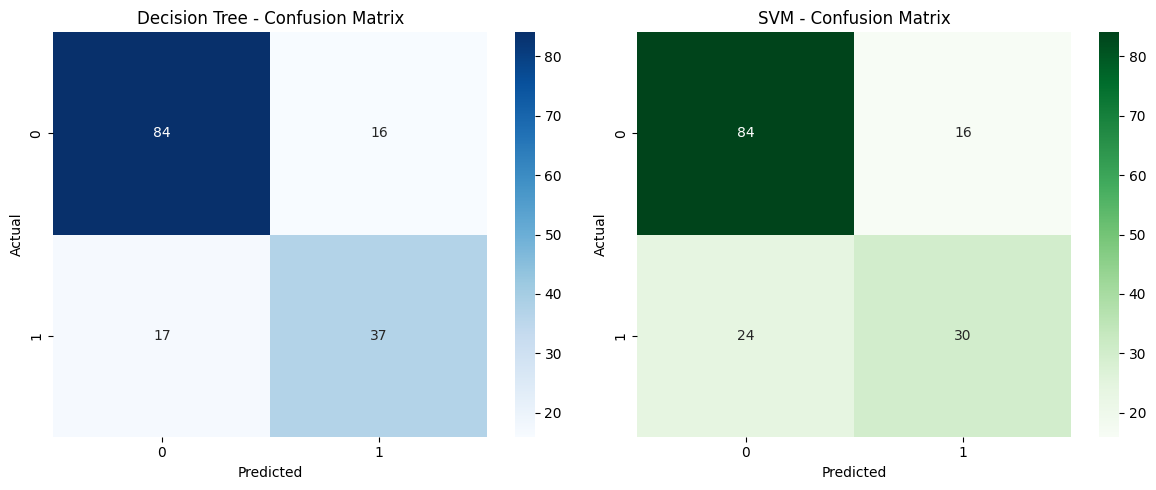


 Model Performance Comparison
        Metric  Decision Tree  SVM Classifier
Train Accuracy       0.794788        0.840391
 Test Accuracy       0.785714        0.740260
     Precision       0.698113        0.652174
        Recall       0.685185        0.555556
      F1-Score       0.691589        0.600000


In [3]:
# PROJECT NAME  : Health Risk Classification (Open-Ended Lab # 7)
# ROLL NUMBER   : 24F-AI-221
# NAME          : Imran Ali Memon
# COURSE        : Machine Learning (AI-3202)


# IMPORTING NECESSARY LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# DATASET DESCRIPTION & LOADING

# Dataset: Pima Indians Diabetes Database
# Direct URL to download dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Column names specified in the Pima Indians dataset documentation
columns = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

# Load dataset into Pandas DataFrame
df = pd.read_csv(url, names=columns)

print("Dataset Overview")
print(df.head())
print("\nDataset Shape:", df.shape)
print("\nDataset Summary Stats:")
print(df.describe().T)

# DATA PREPROCESSING

# In Pima dataset, 0 values in Glucose, BloodPressure, SkinThickness, Insulin,
# and BMI represent MISSING DATA, not actual zero readings.

missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace invalid 0s with NaN
df[missing_cols] = df[missing_cols].replace(0, np.nan)

print("\nMissing values before imputation:")
print(df.isnull().sum())

# Median Imputation (filling missing values with median because median is robust to outliers)
for col in missing_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("\nMissing values after Median Imputation:")
print(df.isnull().sum())


# FEATURE SELECTION & SPLITTING

X = df.drop('Outcome', axis=1) # Features
y = df['Outcome']              # Target (0: No Diabetes, 1: Diabetes)

# Split data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Feature Scaling (Standardization for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MODEL 1 - DECISION TREE CLASSIFIER

# Decision Trees do not strictly require scaled data, but we use X_train for tree clarity.
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt_train = dt_model.predict(X_train)
y_pred_dt_test = dt_model.predict(X_test)


# MODEL 2  SUPPORT VECTOR MACHINE (SVM) CLASSIFIER

# SVM strictly requires feature scaling
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_svm_train = svm_model.predict(X_train_scaled)
y_pred_svm_test = svm_model.predict(X_test_scaled)

# MODEL EVALUATION & METRICS
def evaluate_model(model_name, y_true_train, y_pred_train, y_true_test, y_pred_test):
    train_acc = accuracy_score(y_true_train, y_pred_train)
    test_acc = accuracy_score(y_true_test, y_pred_test)
    prec = precision_score(y_true_test, y_pred_test)
    rec = recall_score(y_true_test, y_pred_test)
    f1 = f1_score(y_true_test, y_pred_test)

    print(f"{model_name}")
    print(f"Training Accuracy : {train_acc * 100:.2f}%")
    print(f"Testing Accuracy  : {test_acc * 100:.2f}%")
    print(f"Precision Score   : {prec:.4f}")
    print(f"Recall Score      : {rec:.4f}")
    print(f"F1-Score          : {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_true_test, y_pred_test))
    return [train_acc, test_acc, prec, rec, f1]

dt_metrics = evaluate_model("Decision Tree Classifier", y_train, y_pred_dt_train, y_test, y_pred_dt_test)
svm_metrics = evaluate_model("Support Vector Machine (SVM)", y_train, y_pred_svm_train, y_test, y_pred_svm_test)

# CONFUSION MATRIX VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_dt_test), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Decision Tree - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_svm_test), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('SVM - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# COMPARISON SUMMARY TABLE
comparison_df = pd.DataFrame({
    'Metric': ['Train Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Decision Tree': dt_metrics,
    'SVM Classifier': svm_metrics
})

print("\n Model Performance Comparison")
print(comparison_df.to_string(index=False))